# Active Contours (Snakes) Segmentation

Implementation and Analysis of Active Contours (Snakes) segmentation technique with internal energy parameters (α and β).

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

## Step 1: Load and Preprocess Image

Image loaded successfully!
Image shape: (980, 1470, 3)


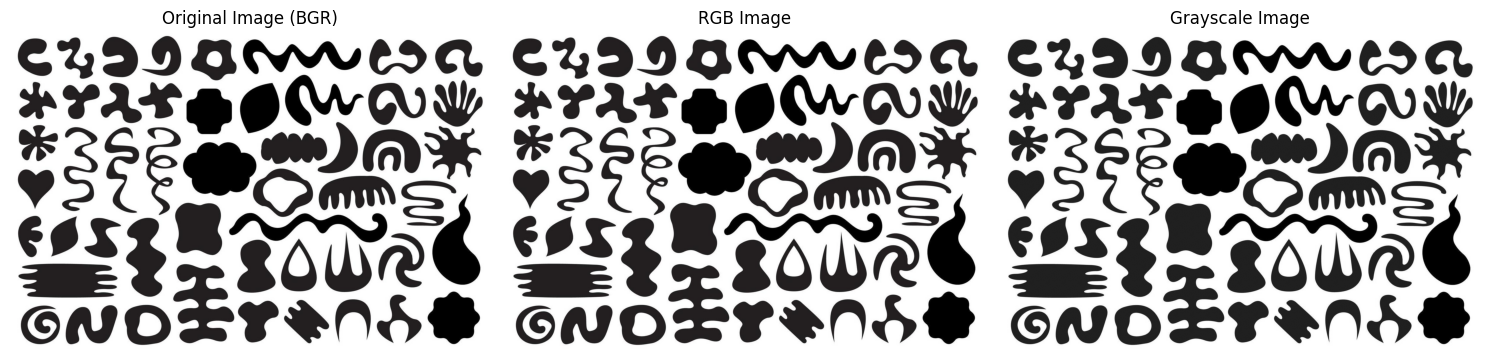

In [16]:
# Load image
img_path = '/Users/sumith/Desktop/5 sem/CV/lab/lab7/uneven.jpg'
img_bgr = cv2.imread(img_path)

# Check if image is loaded successfully
if img_bgr is None:
    print(f"Error: Could not load image from {img_path}")
    print("Please check the file path and ensure the image exists.")
else:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    print(f"Image loaded successfully!")
    print(f"Image shape: {img_rgb.shape}")
    
    # Display original, RGB, and grayscale images
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_bgr[:, :, ::-1])
    axes[0].set_title('Original Image (BGR)')
    axes[0].axis('off')
    
    axes[1].imshow(img_rgb)
    axes[1].set_title('RGB Image')
    axes[1].axis('off')
    
    axes[2].imshow(img_gray, cmap='gray')
    axes[2].set_title('Grayscale Image')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

## Step 2: Create Binary Thresholded Image

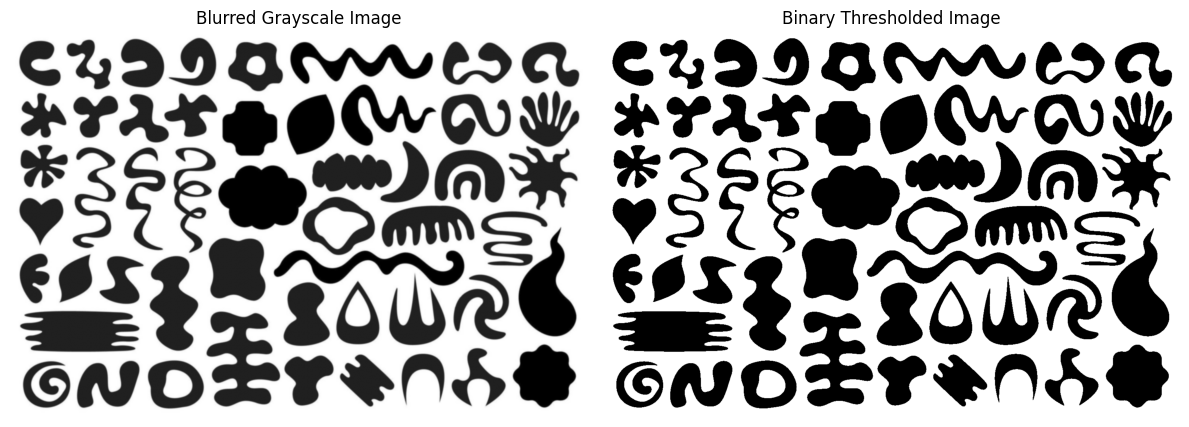

In [17]:
# Apply Gaussian blur for smoothing
img_blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Apply binary thresholding
_, binary_img = cv2.threshold(img_blurred, 127, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_blurred, cmap='gray')
axes[0].set_title('Blurred Grayscale Image')
axes[0].axis('off')

axes[1].imshow(binary_img, cmap='gray')
axes[1].set_title('Binary Thresholded Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Step 3: Find Contours

Number of contours found: 1
Largest contour area: 1438151.0


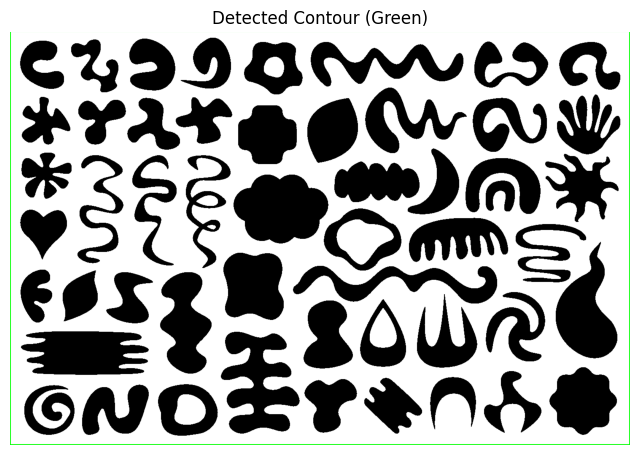

Contour points shape: (4, 2)


In [18]:
# Find contours
contours, _ = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Get the largest contour
if contours:
    largest_contour = max(contours, key=cv2.contourArea)
    print(f"Number of contours found: {len(contours)}")
    print(f"Largest contour area: {cv2.contourArea(largest_contour)}")
    
    # Display contours
    img_contours = cv2.cvtColor(binary_img, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(img_contours, [largest_contour], 0, (0, 255, 0), 2)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(img_contours)
    plt.title('Detected Contour (Green)')
    plt.axis('off')
    plt.show()
    
    # Extract contour points
    contour_points = largest_contour.squeeze().astype(np.float32)
    if len(contour_points.shape) == 1:
        contour_points = np.array([[contour_points[0], contour_points[1]]], dtype=np.float32)
    print(f"Contour points shape: {contour_points.shape}")

## Step 4-5: Internal Energy Matrix with α (Elasticity) and β (Stiffness)

In [19]:
class ActiveContour:
    def __init__(self, contour_points, alpha=0.1, beta=0.1, gamma=0.1, iterations=100, external_force_scale=1.0):
        """
        Active Contour (Snake) implementation
        
        Parameters:
        - contour_points: Initial contour points (n_points, 2)
        - alpha: Elasticity parameter (resistance to stretching)
        - beta: Stiffness parameter (resistance to bending)
        - gamma: Step size for convergence
        - iterations: Number of iterations
        - external_force_scale: Scale factor for external forces
        """
        self.contour = contour_points.copy()
        self.alpha = alpha  # Elasticity
        self.beta = beta    # Stiffness (Bending)
        self.gamma = gamma  # Step size
        self.iterations = iterations
        self.external_force_scale = external_force_scale
        self.history = []
        
    def build_internal_energy_matrix(self, n_points):
        """
        Construct the internal energy matrix for snake evolution.
        Internal Energy = Elasticity (distance between points) + Stiffness (curvature)
        """
        # Create the A matrix for internal energy
        A = np.zeros((n_points, n_points))
        
        for i in range(n_points):
            # Diagonal: elasticity + 2*stiffness
            A[i, i] = self.alpha + 2 * self.beta
            
            # First off-diagonal: -elasticity - stiffness
            A[i, (i + 1) % n_points] = -self.alpha - self.beta
            A[(i + 1) % n_points, i] = -self.alpha - self.beta
            
            # Second off-diagonal: stiffness
            A[i, (i + 2) % n_points] = self.beta
            A[(i + 2) % n_points, i] = self.beta
        
        return A
    
    def compute_external_force(self, image):
        """
        Compute external energy from image edges
        """
        # Compute image gradient magnitude as edge map
        gx = cv2.Sobel(image, cv2.CV_32F, 1, 0, ksize=3)
        gy = cv2.Sobel(image, cv2.CV_32F, 0, 1, ksize=3)
        edge_map = np.sqrt(gx**2 + gy**2)
        
        # Normalize edge map
        edge_map = edge_map / (edge_map.max() + 1e-6)
        
        return edge_map
    
    def get_force_at_point(self, point, edge_map):
        """
        Get interpolated force at a given point from edge map
        """
        x, y = point
        x, y = int(np.clip(x, 0, edge_map.shape[1]-1)), int(np.clip(y, 0, edge_map.shape[0]-1))
        return edge_map[y, x]
    
    def evolve(self, image):
        """
        Evolve the snake over iterations
        """
        n_points = len(self.contour)
        A = self.build_internal_energy_matrix(n_points)
        
        # Compute inverse of (I + gamma*A)
        A_inv = np.linalg.inv(np.eye(n_points) + self.gamma * A)
        
        # Get external force
        edge_map = self.compute_external_force(image)
        
        for iteration in range(self.iterations):
            # Store contour for visualization
            if iteration % 5 == 0:
                self.history.append(self.contour.copy())
            
            # Compute external forces at each contour point
            external_forces = np.zeros_like(self.contour)
            for i, point in enumerate(self.contour):
                force_mag = self.get_force_at_point(point, edge_map)
                # Compute gradient direction at this point
                x, y = int(np.clip(point[0], 0, edge_map.shape[1]-1)), int(np.clip(point[1], 0, edge_map.shape[0]-1))
                
                gx = cv2.Sobel(edge_map, cv2.CV_32F, 1, 0, ksize=3)[y, x]
                gy = cv2.Sobel(edge_map, cv2.CV_32F, 0, 1, ksize=3)[y, x]
                
                norm = np.sqrt(gx**2 + gy**2) + 1e-6
                external_forces[i, 0] = -self.external_force_scale * gx / norm
                external_forces[i, 1] = -self.external_force_scale * gy / norm
            
            # Update snake position
            self.contour = A_inv @ (self.contour + self.gamma * external_forces)
    
    def get_contour(self):
        return self.contour

# Initialize Active Contour with parameters
n_resample = 200
# Resample contour to have uniform number of points
arc_length = np.cumsum(np.sqrt(np.sum(np.diff(contour_points, axis=0)**2, axis=1)))
arc_length = np.insert(arc_length, 0, 0)
resampled = np.interp(np.linspace(0, arc_length[-1], n_resample), arc_length, contour_points[:, 0]), \
            np.interp(np.linspace(0, arc_length[-1], n_resample), arc_length, contour_points[:, 1])
snake_points = np.column_stack(resampled)

print(f"Resampled snake points: {snake_points.shape}")

Resampled snake points: (200, 2)


## Step 6-7: Evolution with Default Parameters (α=0.1, β=0.1)

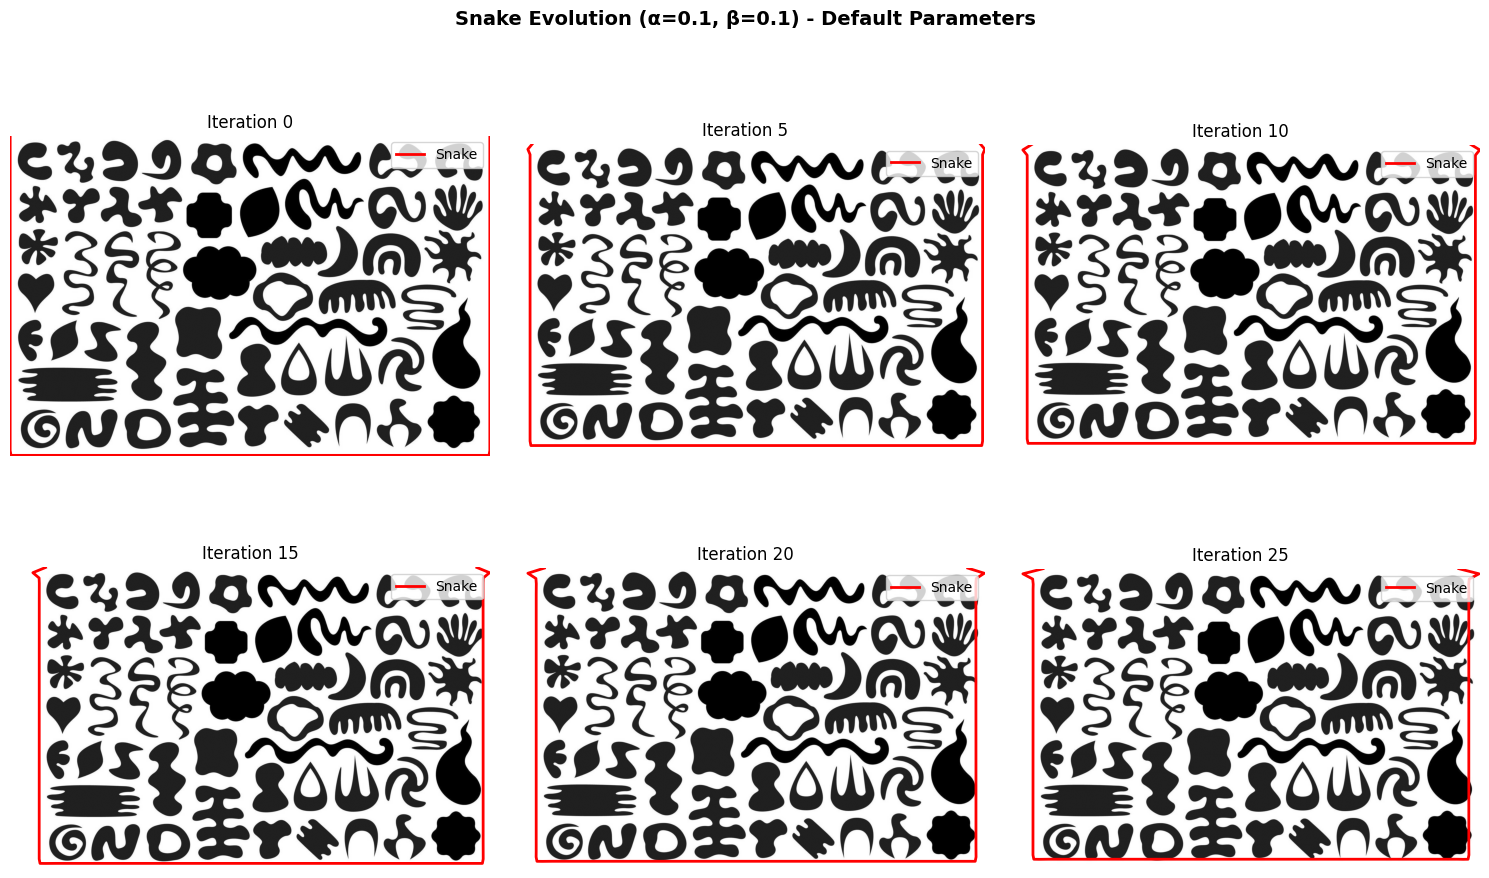

Total iterations stored: 10


In [20]:
# Create and evolve the snake with default parameters
snake = ActiveContour(snake_points, alpha=0.1, beta=0.1, gamma=0.01, iterations=50, external_force_scale=2.0)
snake.evolve(img_gray)

# Display contour evolution every few iterations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Snake Evolution (α=0.1, β=0.1) - Default Parameters', fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx < len(snake.history):
        ax.imshow(img_gray, cmap='gray')
        contour = snake.history[idx]
        ax.plot(contour[:, 0], contour[:, 1], 'r-', linewidth=2, label='Snake')
        ax.set_title(f'Iteration {idx * 5}')
        ax.axis('off')
        ax.legend(loc='upper right')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Total iterations stored: {len(snake.history)}")

## Step 8: Analysis - Effect of α (Elasticity) Parameter

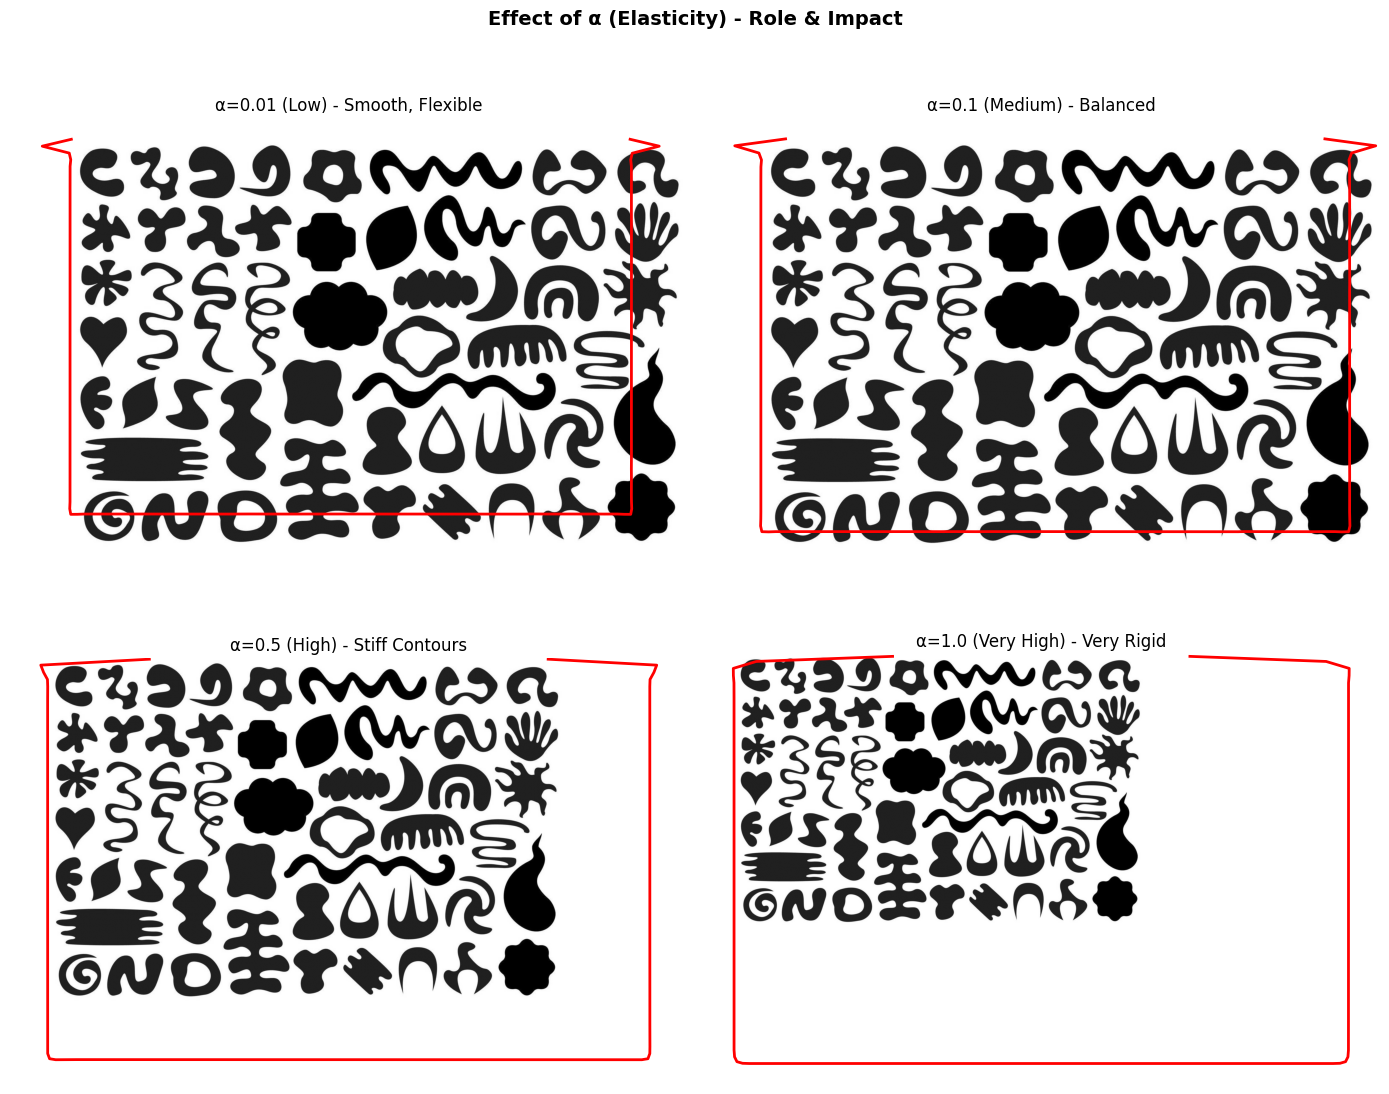

α (Elasticity) Parameter Analysis:
- LOW α (0.01): Snake stretches easily, follows fine details, may become irregular
- MEDIUM α (0.1): Balanced between smoothness and detail following
- HIGH α (0.5): Snake resists stretching, smoother boundaries
- VERY HIGH α (1.0): Snake becomes very rigid, may miss details


In [21]:
# Test different alpha values
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Effect of α (Elasticity) - Role & Impact', fontsize=14, fontweight='bold')

alpha_values = [0.01, 0.1, 0.5, 1.0]
titles = [
    'α=0.01 (Low) - Smooth, Flexible',
    'α=0.1 (Medium) - Balanced',
    'α=0.5 (High) - Stiff Contours',
    'α=1.0 (Very High) - Very Rigid'
]

for idx, (ax, alpha) in enumerate(zip(axes.flat, alpha_values)):
    snake_alpha = ActiveContour(snake_points, alpha=alpha, beta=0.1, gamma=0.01, iterations=50, external_force_scale=2.0)
    snake_alpha.evolve(img_gray)
    
    ax.imshow(img_gray, cmap='gray')
    ax.plot(snake_alpha.contour[:, 0], snake_alpha.contour[:, 1], 'r-', linewidth=2)
    ax.set_title(titles[idx])
    ax.axis('off')

plt.tight_layout()
plt.show()

print("α (Elasticity) Parameter Analysis:")
print("- LOW α (0.01): Snake stretches easily, follows fine details, may become irregular")
print("- MEDIUM α (0.1): Balanced between smoothness and detail following")
print("- HIGH α (0.5): Snake resists stretching, smoother boundaries")
print("- VERY HIGH α (1.0): Snake becomes very rigid, may miss details")

## Step 9: Analysis - Effect of β (Stiffness/Bending) Parameter

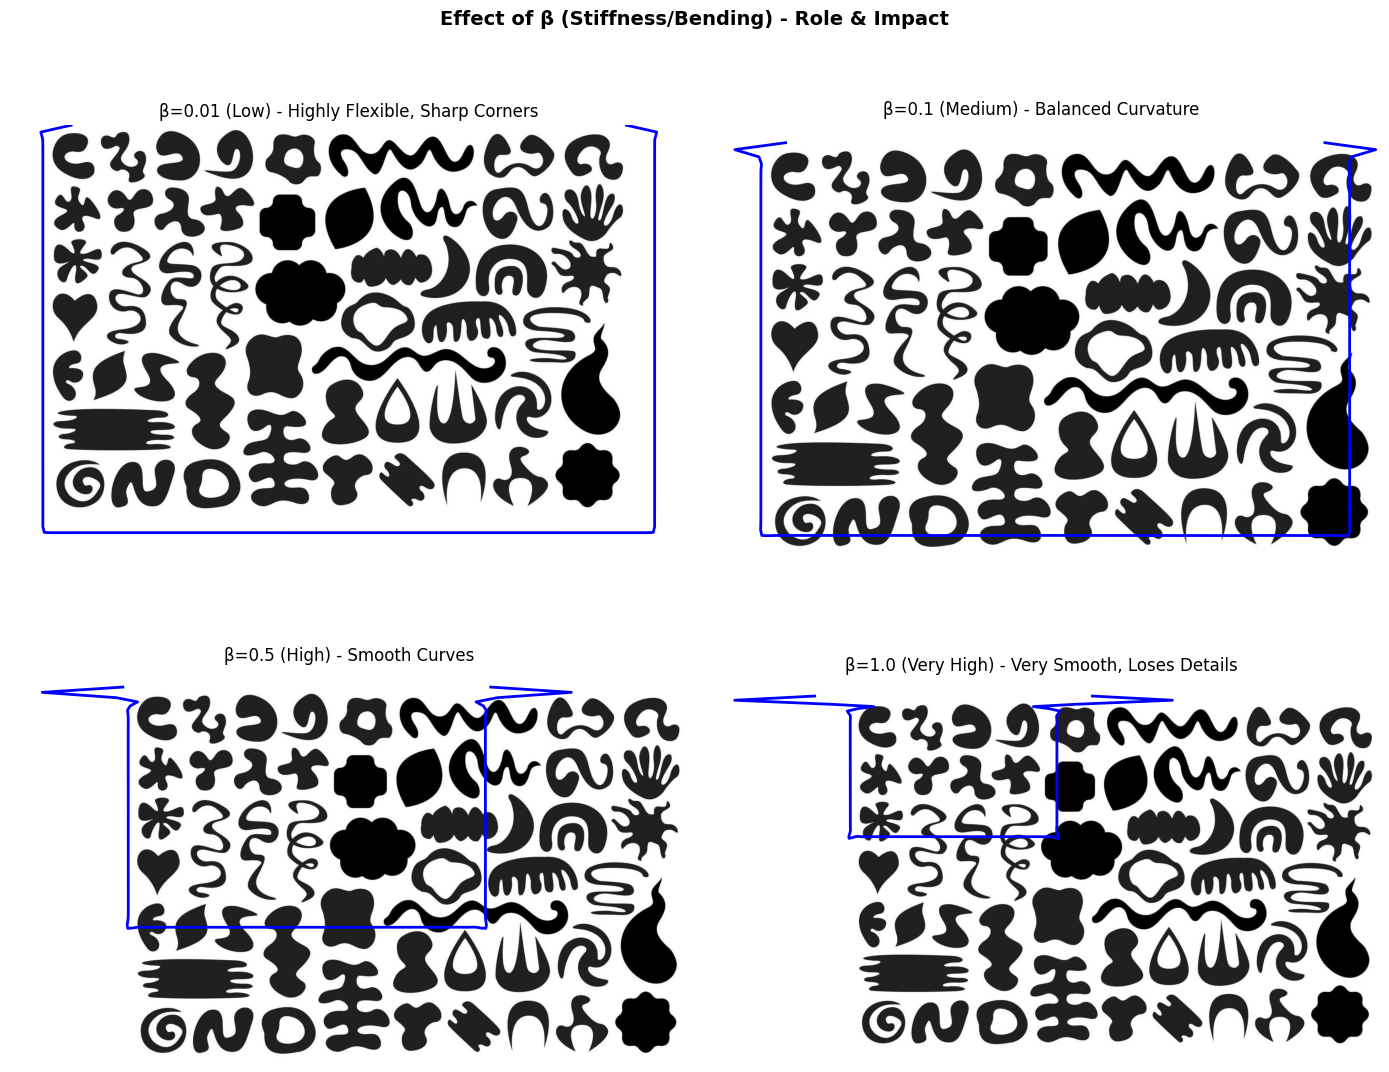

β (Stiffness/Bending) Parameter Analysis:
- LOW β (0.01): Snake can have sharp corners, follows details closely
- MEDIUM β (0.1): Balanced between smoothness and boundary details
- HIGH β (0.5): Snake produces smooth curves, avoids sharp bends
- VERY HIGH β (1.0): Snake becomes too smooth, may miss fine boundary details


In [22]:
# Test different beta values
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Effect of β (Stiffness/Bending) - Role & Impact', fontsize=14, fontweight='bold')

beta_values = [0.01, 0.1, 0.5, 1.0]
titles = [
    'β=0.01 (Low) - Highly Flexible, Sharp Corners',
    'β=0.1 (Medium) - Balanced Curvature',
    'β=0.5 (High) - Smooth Curves',
    'β=1.0 (Very High) - Very Smooth, Loses Details'
]

for idx, (ax, beta) in enumerate(zip(axes.flat, beta_values)):
    snake_beta = ActiveContour(snake_points, alpha=0.1, beta=beta, gamma=0.01, iterations=50, external_force_scale=2.0)
    snake_beta.evolve(img_gray)
    
    ax.imshow(img_gray, cmap='gray')
    ax.plot(snake_beta.contour[:, 0], snake_beta.contour[:, 1], 'b-', linewidth=2)
    ax.set_title(titles[idx])
    ax.axis('off')

plt.tight_layout()
plt.show()

print("β (Stiffness/Bending) Parameter Analysis:")
print("- LOW β (0.01): Snake can have sharp corners, follows details closely")
print("- MEDIUM β (0.1): Balanced between smoothness and boundary details")
print("- HIGH β (0.5): Snake produces smooth curves, avoids sharp bends")
print("- VERY HIGH β (1.0): Snake becomes too smooth, may miss fine boundary details")

## Step 10: Challenges - Snake Starting Far from Object Boundary

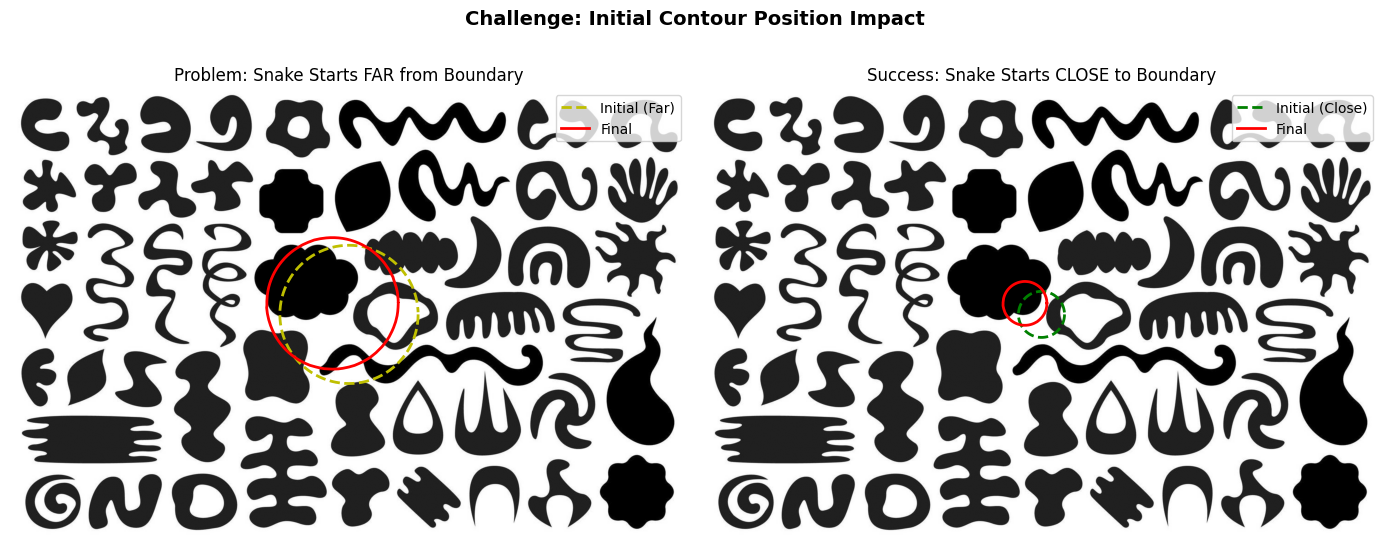


Problems when Snake Starts Far from Object Boundary:
1. WEAK EXTERNAL FORCES: Gradient forces are weak at distance from boundary
2. LOCAL MINIMA TRAPPING: Snake may converge to incorrect local minima
3. CONVERGENCE ISSUES: Limited capture range of the external force field
4. OSCILLATIONS: Snake may oscillate without converging properly
5. MISSING BOUNDARIES: Snake may fail to reach actual object boundaries

Solution: Use multi-scale approaches, balloon forces, or better initialization


In [23]:
# Create initial contour far from object boundary
h, w = img_gray.shape
center_y, center_x = h // 2, w // 2

# Create a circle far from object
far_contour = np.array([
    [center_x + 150 * np.cos(2 * np.pi * i / n_resample), 
     center_y + 150 * np.sin(2 * np.pi * i / n_resample)]
    for i in range(n_resample)
], dtype=np.float32)

# Create another contour close to object
close_contour = np.array([
    [center_x + 50 * np.cos(2 * np.pi * i / n_resample), 
     center_y + 50 * np.sin(2 * np.pi * i / n_resample)]
    for i in range(n_resample)
], dtype=np.float32)

# Evolve both snakes
snake_far = ActiveContour(far_contour, alpha=0.1, beta=0.1, gamma=0.01, iterations=50, external_force_scale=2.0)
snake_close = ActiveContour(close_contour, alpha=0.1, beta=0.1, gamma=0.01, iterations=50, external_force_scale=2.0)

snake_far.evolve(img_gray)
snake_close.evolve(img_gray)

# Display comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Challenge: Initial Contour Position Impact', fontsize=14, fontweight='bold')

# Far start
axes[0].imshow(img_gray, cmap='gray')
axes[0].plot(far_contour[:, 0], far_contour[:, 1], 'y--', linewidth=2, label='Initial (Far)')
axes[0].plot(snake_far.contour[:, 0], snake_far.contour[:, 1], 'r-', linewidth=2, label='Final')
axes[0].set_title('Problem: Snake Starts FAR from Boundary')
axes[0].axis('off')
axes[0].legend()

# Close start
axes[1].imshow(img_gray, cmap='gray')
axes[1].plot(close_contour[:, 0], close_contour[:, 1], 'g--', linewidth=2, label='Initial (Close)')
axes[1].plot(snake_close.contour[:, 0], snake_close.contour[:, 1], 'r-', linewidth=2, label='Final')
axes[1].set_title('Success: Snake Starts CLOSE to Boundary')
axes[1].axis('off')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nProblems when Snake Starts Far from Object Boundary:")
print("1. WEAK EXTERNAL FORCES: Gradient forces are weak at distance from boundary")
print("2. LOCAL MINIMA TRAPPING: Snake may converge to incorrect local minima")
print("3. CONVERGENCE ISSUES: Limited capture range of the external force field")
print("4. OSCILLATIONS: Snake may oscillate without converging properly")
print("5. MISSING BOUNDARIES: Snake may fail to reach actual object boundaries")
print("\nSolution: Use multi-scale approaches, balloon forces, or better initialization")

## Summary: Roles of α and β Parameters

In [24]:
print("="*70)
print("ACTIVE CONTOURS (SNAKES) SEGMENTATION - COMPLETE ANALYSIS")
print("="*70)

print("\n1. ELASTICITY PARAMETER (α) - Tension Term:")
print("   - Controls resistance to stretching/compression")
print("   - Measures distance between consecutive snake points")
print("   - Larger α → smoother snake, resists stretching")
print("   - Smaller α → flexible snake, can follow fine details")
print("   - Formula contribution: α * (distance between points)")

print("\n2. STIFFNESS PARAMETER (β) - Rigidity/Bending Term:")
print("   - Controls resistance to bending/curvature")
print("   - Measures local curvature (second derivative)")
print("   - Larger β → very smooth curves, may miss details")
print("   - Smaller β → flexible boundaries, can have sharp corners")
print("   - Formula contribution: β * (curvature at each point)")

print("\n3. INTERNAL ENERGY MATRIX:")
print("   - Constructed to enforce smoothness through constraints")
print("   - A matrix implements both elasticity and stiffness")
print("   - Snake evolves by minimizing: E = E_internal + E_external")

print("\n4. WHEN PARAMETERS ARE TOO LARGE:")
print("   - α too large: Snake becomes rigid, misses boundary details")
print("   - β too large: Snake becomes overly smooth, loses sharp features")
print("   - Combined: Loss of segmentation accuracy")

print("\n5. WHEN PARAMETERS ARE TOO SMALL:")
print("   - α too small: Snake becomes irregular, disconnected segments")
print("   - β too small: Snake has sharp, unnatural corners")
print("   - Combined: Instability in contour evolution")

print("\n6. OPTIMAL VALUES:")
print("   - Usually α ≈ 0.1 and β ≈ 0.1 for balanced results")
print("   - Depends on image content and desired smoothness")
print("   - May need tuning based on specific application")

print("\n7. INITIAL CONTOUR POSITION CHALLENGE:")
print("   - External force (gradient) field has limited capture range")
print("   - If snake starts too far, weak forces cannot pull it to boundary")
print("   - May need multi-resolution or balloon force approaches")

print("\n" + "="*70)

ACTIVE CONTOURS (SNAKES) SEGMENTATION - COMPLETE ANALYSIS

1. ELASTICITY PARAMETER (α) - Tension Term:
   - Controls resistance to stretching/compression
   - Measures distance between consecutive snake points
   - Larger α → smoother snake, resists stretching
   - Smaller α → flexible snake, can follow fine details
   - Formula contribution: α * (distance between points)

2. STIFFNESS PARAMETER (β) - Rigidity/Bending Term:
   - Controls resistance to bending/curvature
   - Measures local curvature (second derivative)
   - Larger β → very smooth curves, may miss details
   - Smaller β → flexible boundaries, can have sharp corners
   - Formula contribution: β * (curvature at each point)

3. INTERNAL ENERGY MATRIX:
   - Constructed to enforce smoothness through constraints
   - A matrix implements both elasticity and stiffness
   - Snake evolves by minimizing: E = E_internal + E_external

4. WHEN PARAMETERS ARE TOO LARGE:
   - α too large: Snake becomes rigid, misses boundary details
   